In [1]:
import jax
import jax.numpy as jnp
import optax
import flax.linen as nn
from flax.training import train_state
from flax.linen import initializers
from flax.training.common_utils import onehot
from flax.training import checkpoints
from flax import jax_utils
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import math
from itertools import islice, cycle
from flax.training.train_state import TrainState
from flax import struct


jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')


In [2]:
# Don't use TFDS because SSL sometimes is dumb on site; use Jax loader instead
# https://github.com/jax-ml/jax/blob/main/examples/datasets.py

import sys
sys.path.append('../utils')

import datasets
train_images, train_labels, test_images, test_labels = datasets.mnist()
train_images, train_labels, test_images, test_labels = jnp.array(train_images), jnp.array(train_labels), jnp.array(test_images), jnp.array(test_labels)

# np.random.seed(0)
# Create a generator that yields shuffled batches of data without repetition until an epoch is complete
def data_generator(images, labels, batch_size):
    num_samples = images.shape[0]
    # while True:
    #     # Shuffle the data at the beginning of each epoch
    indices = np.random.permutation(num_samples)
    # indices = np.arange(num_samples)
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx]
        yield {'image': images[batch_indices], 'label': labels[batch_indices]}

In [3]:

# Model definition (Linen)
class MLP(nn.Module):
    depth: int
    width: int

    @nn.compact
    def __call__(self, x):
        for i in range(self.depth):
            if i == 0:
                x = nn.Dense(self.width,
                             dtype=jnp.float64,
                             kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(784), maxval=1 / jnp.sqrt(784)),
                             bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(784), maxval=1 / jnp.sqrt(784))
                            )(x)
            elif i == self.depth - 1:
                x = nn.Dense(10, 
                             dtype=jnp.float64,
                            kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200)),
                            bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200))
                                )(x)
            else:
                x = nn.Dense(self.width, 
                             dtype=jnp.float64,
                            kernel_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200)),
                            bias_init=lambda key, shape, dtype: jax.random.uniform(key, shape, dtype, minval=-1 / jnp.sqrt(200), maxval=1 / jnp.sqrt(200))
                            )(x)
            if i < self.depth - 1:
                x = nn.relu(x)
        return x



In [24]:


# The TrainState in Flax doesn't allow for more complex optimziers
# Thus we subclass it and insert the way we need to update 
class MyTrainState(TrainState):
    tx: optax.GradientTransformationExtraArgs = struct.field(pytree_node=False)
    def apply_gradients(self, *, grads, **kwargs):
        value, value_fn, x, labels = kwargs['value'], kwargs['value_fn'], kwargs['x'], kwargs['labels']
        updates, new_opt_state = self.tx.update(
            grads,
            self.opt_state,
            self.params,
            value=value,
            grad=grads,
            value_fn=value_fn,
            x=x,
            labels=labels
        )
        new_params_with_opt = optax.apply_updates(
            self.params, updates)
        return self.replace(
          step=self.step + 1,
          params=new_params_with_opt,
          opt_state=new_opt_state,
        )
        # print(new_params_with_opt)
    
def create_train_state(rng, model, learning_rate, weight_decay, initialization_scale):
    params = model.init(rng, jnp.ones([1, 784], dtype=jnp.float64,))

    # for layer in params: 
    #     for param in params[layer]:
    #         print((params[layer][param].flatten()))
    # print('\n\n')
    params = jax.tree.map(lambda p: initialization_scale * p, params)
    # for layer in params: 
    #     for param in params[layer]:
    #         print(jnp.var(params[layer][param].flatten()))

    # tx = optax.adamw(learning_rate, weight_decay=weight_decay)
    # tx = optax.adam(learning_rate)
    # tx = optax.sgd(learning_rate)
    tx = optax.chain(
        optax.sgd(learning_rate),
        optax.scale_by_backtracking_linesearch(max_backtracking_steps=5, decrease_factor=.5)
    )
    return MyTrainState.create(apply_fn=model.apply, params=params, tx=tx)


In [25]:
### Choose experiment parameters
train_points = 1000
optimization_steps = 100000
batch_size = 200
weight_decay = 0.01
lr = 1e-3
initialization_scale = 8.0
download_directory = "."

depth = 2               # the number of nn.Linear modules in the model
width = 250
activation = 'relu'     # 'relu' or 'tanh' or 'sigmoid' or 'gelu'

log_freq = math.ceil(optimization_steps / 150)
rng = jax.random.PRNGKey(0)

# Create model
model = MLP(depth=depth, width=width)
state = create_train_state(rng, model, lr, weight_decay, initialization_scale)


In [26]:
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
norms = []
last_layer_norms = []
log_steps = []
losses = []
test_ds = data_generator(test_images, test_images, batch_size)

steps = 0
break_outer = False
with tqdm(total=optimization_steps) as pbar:
    @jax.jit
    def mse_loss(logits, labels):
        # return jnp.mean(jnp.sum((logits - labels) ** 2, axis=-1))
        return jnp.mean((logits - labels) ** 2)
    @jax.jit
    def loss_fn_wrapper(params, x, labels):
        logits = model.apply(params, x)
        loss = mse_loss(logits, labels)
        return loss

    grad_fn = jax.value_and_grad(loss_fn_wrapper)

    for epoch in range(optimization_steps // (train_points // batch_size) + 1):
        train_ds = data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size)
        for batch in train_ds:
            if steps + 1 == 2000:
                break_outer = True
                break

            x, labels = batch['image'], batch['label']
            
            @jax.jit
            def batch_loss_accuracy(params, x, labels):
                # Eval model 
                logits = model.apply(params, x)
                loss = mse_loss(logits, labels)
    
                # Get accuracy 
                predicted_labels = jnp.argmax(logits, axis=1) # shape (200,)
                correct = jnp.sum(predicted_labels == labels @ jnp.arange(10)) # convert labels (50, 10) to (50,)
    
                return  loss, correct
    
            def compute_loss_and_accuracy(params, dataset):
                """Computes mean loss of `model` on `dataset`."""
                total_loss = 0
                total_points = 0
                correct = 0
    
                for batch in dataset:
                    x, labels = batch['image'], batch['label']
                
                    batch_loss, batch_accuracy = batch_loss_accuracy(params, x, labels)
    
                    total_loss += batch_loss
                    correct += batch_accuracy
                    total_points += x.shape[0]
                # print(f'{total_points} {correct / total_points} {total_loss / total_points}')
                return total_loss / total_points, (correct / total_points)
            
            # if (steps < 30) or (steps < 150 and steps % 10 == 0) or steps % log_freq == 0:
            if (steps < 150 and steps % 10 == 0) or (steps % log_freq == 0) or (steps % 100 == 0):
                epoch_loss, epoch_acc = compute_loss_and_accuracy(
                        state.params, data_generator(train_images[0:train_points], train_labels[0:train_points], batch_size=50)
                )
                train_losses.append(
                    epoch_loss
                )
                train_accuracies.append(
                    epoch_acc
                )
    
                epoch_loss, epoch_acc = compute_loss_and_accuracy(
                        state.params, data_generator(test_images, test_labels, batch_size=50)
                )
                test_losses.append(
                    epoch_loss
                )
                test_accuracies.append(
                    epoch_acc
                )
    
                log_steps.append(steps)
                params_leaves = jax.tree_util.tree_leaves(state.params)
                norms.append(jnp.linalg.norm(jnp.concatenate([jnp.ravel(p) for p in params_leaves])))
                # last_layer_norms.append(jnp.linalg.norm(state.params['Dense_2']['kernel']))
                pbar.set_description("L: {0:1.1e}|{1:1.1e}. A: {2:2.1f}%|{3:2.1f}%".format(
                    train_losses[-1],
                    test_losses[-1],
                    train_accuracies[-1] * 100, 
                    test_accuracies[-1] * 100))
            
            loss, grads = grad_fn(state.params, x, labels)   
            losses.append(loss)
    
            # print('Running SMW')
            lamb = 5e-2
            _, jvp_output = jax.jvp(lambda p: state.apply_fn(p, x), (state.params,), (grads,))
            jacobian_fn = jax.jacrev(
                lambda params, x: state.apply_fn(params, x)
            )(state.params, x)
            flat_jacobian = []
            for layer in jacobian_fn['params'].values():
                for param in layer.values():
                    flat_jacobian.append(param.reshape(batch_size, -1))
            jacobian_fn = jnp.concatenate(flat_jacobian, axis=1)
            mat = jacobian_fn @ jacobian_fn.T
    
            out = jnp.linalg.solve(jnp.eye(mat.shape[0]) + 1 / lamb * mat, jvp_output / (lamb ** 2))
            _, vjp_fn = jax.vjp( lambda params, x: state.apply_fn(params, x), state.params, x)
            adjustment = vjp_fn(out)[0] 
            grads = jax.tree.map(lambda a, b: 1 / lamb * a - b, grads, adjustment)
    
            # state = state.apply_gradients(grads=grads)
            state = state.apply_gradients(
                grads=grads,
                value=loss,
                grad=grads,
                value_fn=loss_fn_wrapper,
                x=x,
                labels=labels,
            )
            
            steps += 1
            pbar.set_description("L: {0:1.2e}|{1:1.1e}. A: {2:2.1f}%|{3:2.1f}%".format(
                    loss,
                    test_losses[-1],
                    train_accuracies[-1] * 100, 
                    test_accuracies[-1] * 100))
    
            pbar.update(1)
        if break_outer: 
            break


  0%|          | 0/100000 [00:00<?, ?it/s]

KeyboardInterrupt: 

/tmp/ipykernel_1826973/2334860881.py:5: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, None)


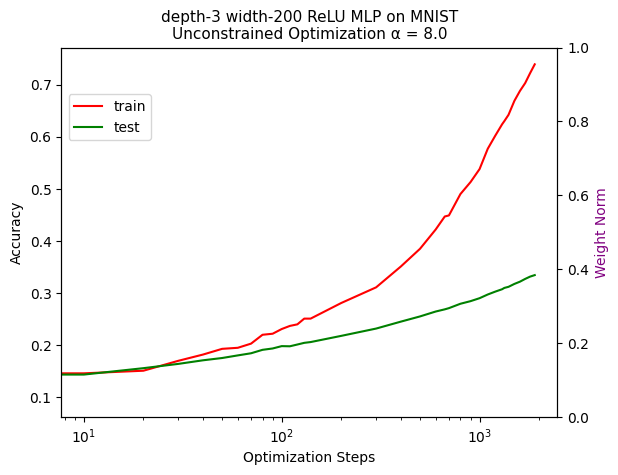

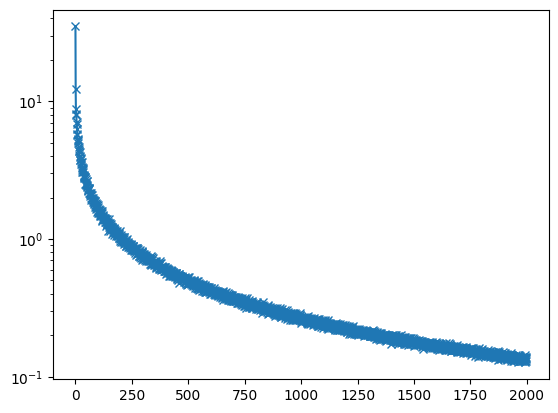

In [23]:
ax = plt.subplot(1, 1, 1)
plt.plot(log_steps, train_accuracies, color='red', label='train')
plt.plot(log_steps, test_accuracies, color='green', label='test')
plt.xscale('log')
plt.xlim(0, None)
plt.xlabel("Optimization Steps")
# plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.legend(loc=(0.015, 0.75))

ax2 = ax.twinx()
ax2.set_ylabel("Weight Norm", color='purple')
# ax2.plot(log_steps, norms, color='purple', label='weight norm')
# plt.legend(loc=(0.015, 0.65))
plt.title(f"depth-3 width-200 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)
plt.show()

plt.semilogy(losses[:], 'x-')
plt.show()

/tmp/ipykernel_1826973/2334860881.py:5: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, None)


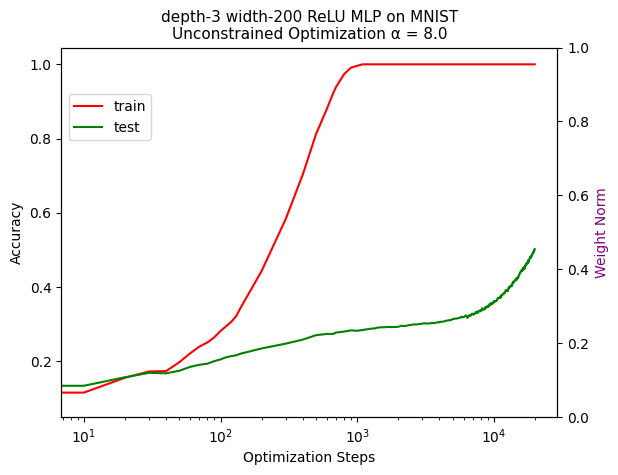

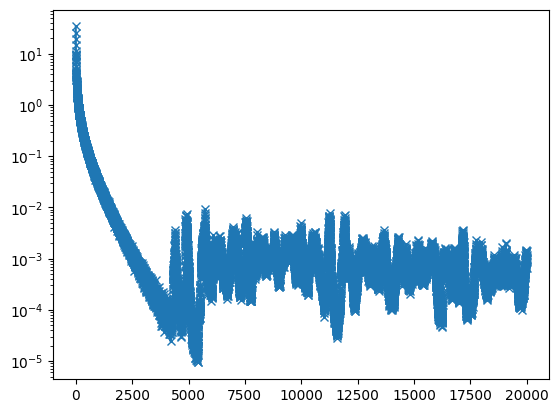

In [17]:
ax = plt.subplot(1, 1, 1)
plt.plot(log_steps, train_accuracies, color='red', label='train')
plt.plot(log_steps, test_accuracies, color='green', label='test')
plt.xscale('log')
plt.xlim(0, None)
plt.xlabel("Optimization Steps")
# plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.legend(loc=(0.015, 0.75))

ax2 = ax.twinx()
ax2.set_ylabel("Weight Norm", color='purple')
# ax2.plot(log_steps, norms, color='purple', label='weight norm')
# plt.legend(loc=(0.015, 0.65))
plt.title(f"depth-3 width-200 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)
plt.show()

plt.semilogy(losses[:], 'x-')
plt.show()

/tmp/ipykernel_1390963/2334860881.py:5: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, None)


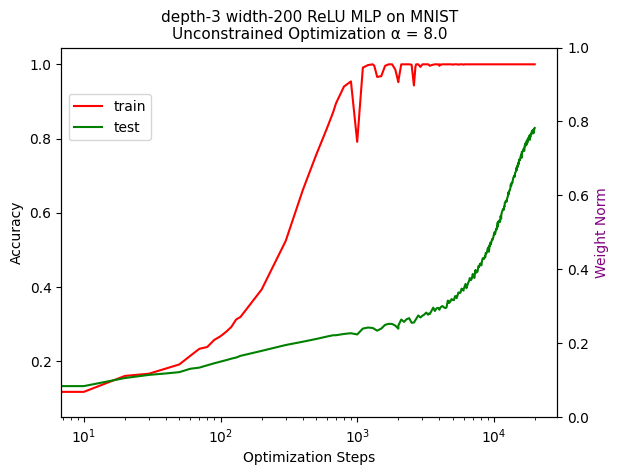

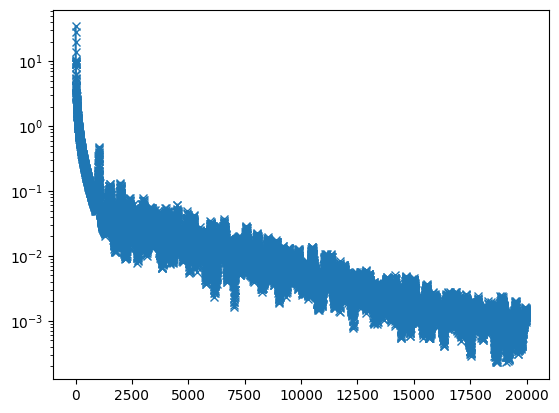

In [26]:
ax = plt.subplot(1, 1, 1)
plt.plot(log_steps, train_accuracies, color='red', label='train')
plt.plot(log_steps, test_accuracies, color='green', label='test')
plt.xscale('log')
plt.xlim(0, None)
plt.xlabel("Optimization Steps")
# plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.legend(loc=(0.015, 0.75))

ax2 = ax.twinx()
ax2.set_ylabel("Weight Norm", color='purple')
# ax2.plot(log_steps, norms, color='purple', label='weight norm')
# plt.legend(loc=(0.015, 0.65))
plt.title(f"depth-3 width-200 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)
plt.show()

plt.semilogy(losses[:], 'x-')
plt.show()

/tmp/ipykernel_1374660/366938443.py:5: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, None)


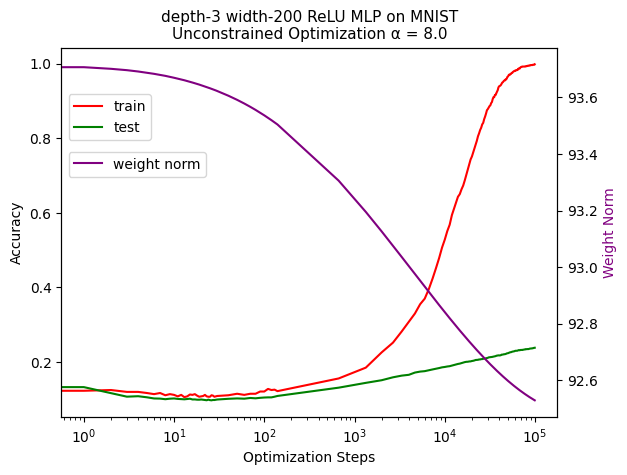

In [104]:
ax = plt.subplot(1, 1, 1)
plt.plot(log_steps, train_accuracies, color='red', label='train')
plt.plot(log_steps, test_accuracies, color='green', label='test')
plt.xscale('log')
plt.xlim(0, None)
plt.xlabel("Optimization Steps")
# plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.legend(loc=(0.015, 0.75))

ax2 = ax.twinx()
ax2.set_ylabel("Weight Norm", color='purple')
ax2.plot(log_steps, norms, color='purple', label='weight norm')
plt.legend(loc=(0.015, 0.65))
plt.title(f"depth-3 width-200 ReLU MLP on MNIST\nUnconstrained Optimization α = {initialization_scale}", fontsize=11)
plt.show()

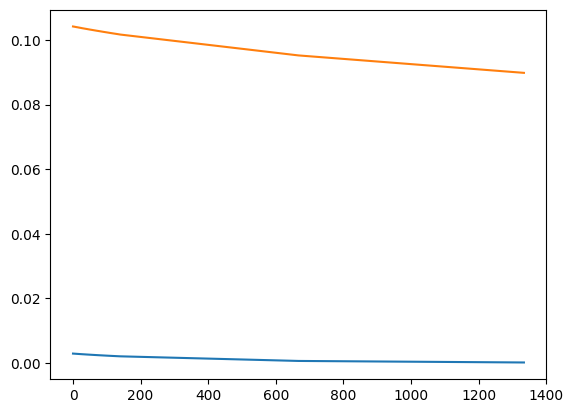

In [50]:
plt.plot(log_steps, train_losses)
plt.plot(log_steps, test_losses)

In [ ]:
# Manually set weights... 
# Load weights from the saved file
loaded_weights = np.load('model_weights.npz')

# print(loaded_weights.keys())
# print(state.params['Dense_0']['kernel'].shape)
# state.params['Dense_0']['kernel'] = jnp.array(loaded_weights['layer_0'].T)
# print(state.params['Dense_0']['kernel'].shape)

# print(state.params['Dense_0']['bias'].shape)
# state.params['Dense_0']['bias'] = jnp.array(loaded_weights['layer_1'])
# print(state.params['Dense_0']['bias'].shape)

# print(state.params['Dense_1']['kernel'].shape)
# state.params['Dense_1']['kernel'] = jnp.array(loaded_weights['layer_2'].T)
# print(state.params['Dense_1']['kernel'].shape)

# print(state.params['Dense_1']['bias'].shape)
# state.params['Dense_1']['bias'] = jnp.array(loaded_weights['layer_3'])
# print(state.params['Dense_1']['bias'].shape)

# print(state.params['Dense_2']['kernel'].shape)
# state.params['Dense_2']['kernel'] = jnp.array(loaded_weights['layer_4'].T)
# print(state.params['Dense_2']['kernel'].shape)

# print(state.params['Dense_2']['bias'].shape)
# state.params['Dense_2']['bias'] = jnp.array(loaded_weights['layer_5'])
# print(state.params['Dense_2']['bias'].shape)
# print(state.params['Dense_2']['bias'].dtype)

# Assign loaded weights to the JAX model
# for i in range(len(jax_mlp.params)):
#     jax_mlp.params[i] = loaded_weights[f'layer_{i}']

# print(jax.tree_util.tree_map(lambda p: p.shape, state.params))